# This notebook demonstrates plotting diurnal cycle composites of MCS precipitation Hovmoller diagram by seasons
## The monthly data is produced by: 
* /Analysis/calc_tbpf_mcs_monthly_rainhov.py

In [1]:
import numpy as np
import glob, os
import xarray as xr
import pandas as pd
from scipy import fftpack
import time, datetime, calendar, pytz
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import colorcet as cc
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.geoaxes as crs_geoaxes
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import colormath, colormath.color_objects, colormath.color_conversions
from colormath.color_objects import sRGBColor
import urllib
import re
%matplotlib inline

In [2]:
# Sepcify directory of the MCS stats file
rootdir = '/pscratch/sd/w/wcmca1/SCREAM-cess/'
gpmdir = f'{rootdir}gpm/stats/monthly/'
m1dir = f'{rootdir}control_nudged/stats/monthly/'
m2dir = f'{rootdir}control_free/stats/monthly/'
region = 'CUS'

name_map1 = {'obs':'OBS', 'm1':'EAMxx-Nudged', 'm2':'EAMxx-Free'}
name_map2 = {'obs':'OBS', 'm1':'EAMxx-N', 'm2':'EAMxx-F'}

datetime_range = pd.to_datetime(['2019-09-01T00', '2020-09-01T00'])
dates = pd.date_range(start=min(datetime_range), end=max(datetime_range), freq='MS').strftime('%Y%m')
    
# Find all files from the list of dates
m1files = []
m2files = []
gpmfiles = []

for dd in dates:
    m1files = m1files + sorted(glob.glob(f'{m1dir}mcs_rainhov_{region}_{dd}*.nc'))
    m2files = m2files + sorted(glob.glob(f'{m2dir}mcs_rainhov_{region}_{dd}*.nc'))
    gpmfiles = gpmfiles + sorted(glob.glob(f'{gpmdir}mcs_rainhov_{region}_{dd}*.nc'))

# nyears_gpm = 1
# nyears_m1 = 1
# nyears_m2 = 1
nfiles_gpm = len(gpmfiles)
nfiles_m1 = len(m1files)
nfiles_m2 = len(m2files)
print(f'Number of files (OBS): {nfiles_gpm}')
print(f'Number of files (m1): {nfiles_m1}')
print(f'Number of files (m2): {nfiles_m2}')

figdir = f'/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/'
os.makedirs(figdir, exist_ok=True)
print(figdir)

Number of files (OBS): 6
Number of files (m1): 6
Number of files (m2): 6
/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/


In [3]:
# # Sepcify directory of the MCS track stats file
# # rootdir = '/pscratch/sd/s/souravt/PyFLEXTRKR/TGW_MCS/HIST/'
# rootdir = '/global/cfs/cdirs/m1867/www/PyFLEXTRKR/sample_data/TGW_MCS/'
# # Specify region name
# # region = 'SGP'
# region = 'NGP'

# obsdir = f'{rootdir}OBS/stats/monthly/'
# wrfdir = f'{rootdir}WRF/stats/monthly/'
# obsfiles = sorted(glob.glob(f'{obsdir}mcs_rainhov_{region}*.nc'))
# wrffiles = sorted(glob.glob(f'{wrfdir}mcs_rainhov_{region}*.nc'))

# nfiles_gpm = len(obsfiles)
# nfiles_wrf = len(wrffiles)
# print(f'Number of files (OBS): {nfiles_gpm}')
# print(f'Number of files (WRF): {nfiles_wrf}')

# # figdir = f'/global/cfs/cdirs/m2637/zfeng/TGW_MCS/figures/'
# figdir = f'/global/cfs/cdirs/m1867/www/PyFLEXTRKR/sample_data/TGW_MCS/figures/'
# os.makedirs(figdir, exist_ok=True)
# print(f'Fig directory: {figdir}')

## These customed functions enables use of [NCL colormaps](https://www.ncl.ucar.edu/Document/Graphics/color_table_gallery.shtml)

In [4]:
color_obj_dict = {'sRGB':colormath.color_objects.sRGBColor,
                  'HSV':colormath.color_objects.HSVColor,
                  'Lab':colormath.color_objects.LabColor,
                  'LCHuv':colormath.color_objects.LCHuvColor,
                  'LCHab':colormath.color_objects.LCHabColor,
                  'XYZ':colormath.color_objects.XYZColor}

def __rgb_to_array(rgb_color):
    r = np.minimum(1, round(rgb_color.rgb_r*10000)/10000)
    g = np.minimum(1, round(rgb_color.rgb_g*10000)/10000)
    b = np.minimum(1, round(rgb_color.rgb_b*10000)/10000)
    return r,g,b


def create_palette(start_rgb, end_rgb, n, colorspace):
    # convert start and end to a point in the given colorspace
    start = colormath.color_conversions.convert_color(start_rgb, colorspace).get_value_tuple()
    end = colormath.color_conversions.convert_color(end_rgb, colorspace).get_value_tuple()

    # create a set of n points along start to end
    points = list(zip(*[np.linspace(start[i], end[i], n) for i in range(3)]))

    # create a color for each point and convert back to rgb
    rgb_colors = [colormath.color_conversions.convert_color(colorspace(*point), sRGBColor) for point in points]

    # finally convert rgb colors back to hex
    return [__rgb_to_array(color) for color in  rgb_colors]


def __retrive_NCL_webcontent(cmapname):
    target_url = 'https://www.ncl.ucar.edu/Document/Graphics/ColorTables/Files/%s.rgb' % cmapname
    request = urllib.request.urlopen(target_url)
    return request


def __collect_discrete_NCL_cmap(cmapname):
    rawdata = __retrive_NCL_webcontent(cmapname)
    
    cmap_color_list = list()
    
    color_section_sig = 0
    
    for line in rawdata:
        
        line_decode = line.decode('utf-8')
        info = re.split('\s+', line_decode.replace('\n','').replace('^\s+',''))

        if color_section_sig==1:
            if info[0]=='' and len(info)>=3:
                if np.maximum(np.maximum(float(info[1]), float(info[2])), float(info[3]))>1:
                    cmap_color_list.append((float(info[1])/255, float(info[2])/255, float(info[3])/255))
                else:
                    cmap_color_list.append((float(info[1]), float(info[2]), float(info[3])))
            if len(info)==3:
                if ';' in info[0] or '#' in info[0]:
                    whatisthis = 's'
                else:
                    if np.maximum(np.maximum(float(info[0]), float(info[1])), float(info[2]))>1:
                        cmap_color_list.append((float(info[0])/255, float(info[1])/255, float(info[2])/255))
                    else:
                        cmap_color_list.append((float(info[0]), float(info[1]), float(info[2])))
        
        if 'ncolors' in str(info[0]):
            color_section_sig = 1  # meaning now we are at color lines (or "r g b" line)

    return cmap_color_list


def __cmap_refinement(raw_cmap_rgb, n_interpolate=10, workspace=color_obj_dict['sRGB']):
    # workspace:  choose which color space the refinement is conducted.
    #             refer to https://stackoverflow.com/questions/55032648/given-a-start-color-and-a-middle-color-how-to-get-the-remaining-colors-python

    n_in = len(raw_cmap_rgb)

    new_array = list()

    for i in np.arange(n_in-1):
        out_colors = create_palette(sRGBColor(*raw_cmap_rgb[i], is_upscaled=False), sRGBColor(*raw_cmap_rgb[i+1], is_upscaled=False), n_interpolate+1, workspace)
        for j in np.arange(len(out_colors)-1):
            new_array.append(out_colors[j])

    return new_array


def generate_NCL_cmap(cmapname, cont_opt=False, cont_param_n=10, cont_param_ws='sRGB',
                      white_first=False, white_ext=False, reverse_cmap=False):
    # description:
    #     cmapname:      taken as shown on the NCL website
    #     cont_opt:      to convert the discreate colormap to continuous colormap
    #     cont_param_n:  how many "intermediate" colors to be inserted to the nearby discreate colors
    #     cont_param_ws: color space to conduct interploation. Default to "sRGB", which should work for most cases
    #     white_first:   whether to set the first color as white. May be useful if the minimum does not mean anything
    #     white_ext:     whether to add this above white as an extended color (when set to True), or just replace the first color (when set to False).
    #     reverse_cmap:  similar to "_r" in colormap.
    # note:  reverse_cmap is applied first, then white_first option.

    cmap_discrete_raw = __collect_discrete_NCL_cmap(cmapname)

    if reverse_cmap==True:
        cmap_discrete_raw.reverse()

    if white_first==True:
        if white_ext==True:
            cmap_discrete = list()
            cmap_discrete.append((1,1,1))
            for i in np.arange(len(cmap_discrete_raw)):
                cmap_discrete.append(cmap_discrete_raw[int(i)])
        else:
            cmap_discrete = cmap_discrete_raw.copy()
        cmap_discrete[0] = (1,1,1)
    else:
        cmap_discrete = cmap_discrete_raw

    if cont_opt==False:
        out_cmap = cmap_discrete

    if cont_opt==True:
        out_cmap = __cmap_refinement(cmap_discrete, n_interpolate=cont_param_n, workspace=color_obj_dict[cont_param_ws])

    return mpl.colors.ListedColormap(out_cmap)

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    """ Truncate colormap.
    """
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

## Function to compute diurnal cycle amplitude and phase for 1D data

In [5]:
def harmonic_phase_amplitude(var, nharm, hr1, binsize=1.0):
    """
    Calculates the harmonic phase and amplitude for the requested number
    of harmonics. The phase indicates the location of the peak closest to
    T=0 for each harmonic along the T-axis--it can be on either side of 0.
    Arguments:
       var   = array to be analyzed, XT ordering assumed.
       nharm = number of harmonics to calculate
       hr1   = hour of the first time in the time series--used to adj. phase to be 0 at 0 hrs
       binsize = size of the hour bin for calculating phase. default=1.0
    Returns:
       amp[nharm] = amplitude of each harmonic
       phs[nharm] = phase of each harmonic, with 0 phase set to hour 0
       pvar[nharm] = percent variance explained
    Created: William.Gustafson@pnnl.gov, 17-Jan-2014
    Last modified: William.Gustafson@pnnl.gov, 22-Jan-2014
    Modified by: Zhe.Feng@pnnl.gov, 10-Jan-2019
    """
    nt = var.shape[-1]
    w = float(nt) * binsize / (2.*np.arccos(-1.))
    ft = fftpack.fft(var, axis=-1)

    # 0th index returned by fft is the trend, so harmonics start at 1
    ampall = np.abs(ft)[1:] * 2./float(nt)  # need all amplitudes to get total variance
    amp = ampall[0:nharm]
    phs = np.angle(ft)[1:nharm+1]

    totvar = 0.5*np.sum(ampall*ampall)  # total variance
    zeros = np.where(totvar < 1e-12, True, False)  # Need to mask out zero variance values for getting percent values
    totvar_nozeros = np.where(zeros, 1., totvar)
    pvar = np.empty_like(amp)

    for n in range(nharm):
        np1 = n + 1  # adjust by one to get the harmonic number vs. its index
        phs_offset_max = float(nt) * binsize / float(np1)  # max possible phase offset for this harmonic

        # Have to switch rotation direction of the phase angle to get
        # where first peak occurs. We want it to indicate the angle where
        # the peak occurs. We also do the shift here for the offset due
        # to the first hour not being at 0 (what was sent into this routine).
        phs[n] = phs_offset_max - phs[n] * w / float(np1) + hr1

        # Now, we adjust for a phase that might be a multiple of the given harmonic.
        phs[n] = np.where(phs[n]>phs_offset_max, phs[n]-phs_offset_max, phs[n])
        phs[n] = np.where(phs[n]<0, phs[n] + float(nt)*binsize/float(np1), phs[n])

        # Get percent variance explained by each harmonic.
        pvar[n] = np.where(zeros, 0., 100.*(0.5*amp[n]*amp[n])/totvar_nozeros)
    
    return amp, phs, pvar

## Function to compute diurnal cycle amplitude and phase for 2D data

In [6]:
def harmonic_phase_amplitude2d(var, nharm, hr1, binsize=1.0):
    """
    Calculates the harmonic phase and amplitude for the requested number
    of harmonics. The phase indicates the location of the peak closest to
    T=0 for each harmonic along the T-axis--it can be on either side of 0.
    Arguments:
       var   = array to be analyzed, YXT ordering assumed.
       nharm = number of harmonics to calculate
       hr1   = hour of the first time in the time series--used to adj. phase to be 0 at 0 hrs
       binsize = size of the hour bin for calculating phase. default=1.0
    Returns:
       amp[nharm] = amplitude of each harmonic
       phs[nharm] = phase of each harmonic, with 0 phase set to hour 0
       pvar[nharm] = percent variance explained
    Created: William.Gustafson@pnnl.gov, 17-Jan-2014
    Last modified: William.Gustafson@pnnl.gov, 22-Jan-2014
    Modified by: Zhe.Feng@pnnl.gov, 10-Jan-2019
    """
    nt = var.shape[-1]
    w = float(nt) * binsize / (2.*np.arccos(-1.))
    ft = fftpack.fft(var, axis=-1)

    # 0th index returned by fft is the trend, so harmonics start at 1
    ampall = np.abs(ft)[:, 1:] * 2./float(nt)  # need all amplitudes to get total variance
    amp = ampall[:, 0:nharm]
    phs = np.angle(ft)[:, 1:nharm+1]

    totvar = 0.5*np.sum(ampall*ampall, axis=1)  # total variance
    zeros = np.where(totvar < 1e-12, True, False)  # Need to mask out zero variance values for getting percent values
    totvar_nozeros = np.where(zeros, 1., totvar)
    pvar = np.empty_like(amp)

    for n in range(nharm):
        np1 = n + 1  # adjust by one to get the harmonic number vs. its index
        phs_offset_max = float(nt) * binsize / float(np1)  # max possible phase offset for this harmonic

        # Have to switch rotation direction of the phase angle to get
        # where first peak occurs. We want it to indicate the angle where
        # the peak occurs. We also do the shift here for the offset due
        # to the first hour not being at 0 (what was sent into this routine).
        phs[:,n] = phs_offset_max - phs[:,n] * w / float(np1) + hr1

        # Now, we adjust for a phase that might be a multiple of the given harmonic.
        phs[:,n] = np.where(phs[:,n]>phs_offset_max, phs[:,n]-phs_offset_max, phs[:,n])
        phs[:,n] = np.where(phs[:,n]<0, phs[:,n] + float(nt)*binsize/float(np1), phs[:,n])

        # Get percent variance explained by each harmonic.
        pvar[:,n] = np.where(zeros, 0., 100.*(0.5*amp[:,n]*amp[:,n])/totvar_nozeros)
    
    return amp, phs, pvar

In [7]:
# Read OBS data
dsobs = xr.open_mfdataset(gpmfiles, concat_dim='time', combine='nested')
lon_obs = dsobs.lon

In [8]:
startlat = dsobs.attrs['startlat']
endlat = dsobs.attrs['endlat']
startlon = dsobs.attrs['startlon']
endlon = dsobs.attrs['endlon']
print(f'Longitude range: {startlon, endlon}')
print(f'Latitude range: {startlat, endlat}')

Longitude range: (-110.0, -80.0)
Latitude range: (30.0, 49.0)


In [9]:
# Read m1 data
dsm1 = xr.open_mfdataset(m1files, concat_dim='time', combine='nested')
lon_m1 = dsm1.lon

In [10]:
# Read m2 data
dsm2 = xr.open_mfdataset(m2files, concat_dim='time', combine='nested')
lon_m2 = dsm2.lon

In [11]:
# Subset Hovmoller dataset by season, group by hour of the day, and average on the time dimension (OBS)
totpcphovdiur_obs_MAM = dsobs.sel(time=dsobs['time.season'] == 'MAM').precipitation.groupby('time.hour').mean(dim='time')
mcspcphovdiur_obs_MAM = dsobs.sel(time=dsobs['time.season'] == 'MAM').mcs_precipitation.groupby('time.hour').mean(dim='time')
totpcphovdiur_obs_JJA = dsobs.sel(time=dsobs['time.season'] == 'JJA').precipitation.groupby('time.hour').mean(dim='time')
mcspcphovdiur_obs_JJA = dsobs.sel(time=dsobs['time.season'] == 'JJA').mcs_precipitation.groupby('time.hour').mean(dim='time')

In [12]:
# Subset Hovmoller dataset by season, group by hour of the day, and average on the time dimension (m1)
totpcphovdiur_m1_MAM = dsm1.sel(time=dsm1['time.season'] == 'MAM').precipitation.groupby('time.hour').mean(dim='time')
mcspcphovdiur_m1_MAM = dsm1.sel(time=dsm1['time.season'] == 'MAM').mcs_precipitation.groupby('time.hour').mean(dim='time')
totpcphovdiur_m1_JJA = dsm1.sel(time=dsm1['time.season'] == 'JJA').precipitation.groupby('time.hour').mean(dim='time')
mcspcphovdiur_m1_JJA = dsm1.sel(time=dsm1['time.season'] == 'JJA').mcs_precipitation.groupby('time.hour').mean(dim='time')

In [13]:
# Subset Hovmoller dataset by season, group by hour of the day, and average on the time dimension (m2)
totpcphovdiur_m2_MAM = dsm2.sel(time=dsm2['time.season'] == 'MAM').precipitation.groupby('time.hour').mean(dim='time')
mcspcphovdiur_m2_MAM = dsm2.sel(time=dsm2['time.season'] == 'MAM').mcs_precipitation.groupby('time.hour').mean(dim='time')
totpcphovdiur_m2_JJA = dsm2.sel(time=dsm2['time.season'] == 'JJA').precipitation.groupby('time.hour').mean(dim='time')
mcspcphovdiur_m2_JJA = dsm2.sel(time=dsm2['time.season'] == 'JJA').mcs_precipitation.groupby('time.hour').mean(dim='time')

In [14]:
# # Group Hovmoller data by hour of the day, and average on the time dimension (OBS)
# totpcphovdiur_obs = dsobs.precipitation.groupby('time.hour').mean(dim='time')
# mcspcphovdiur_obs = dsobs.mcs_precipitation.groupby('time.hour').mean(dim='time')
# # Longitude values
# lon_obs = dsobs.lon

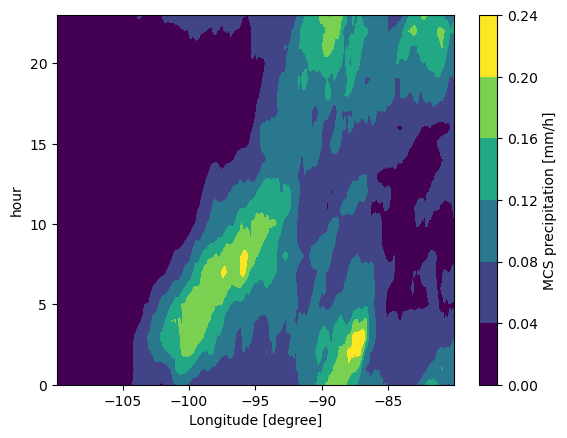

In [15]:
mcspcphovdiur_obs_JJA.plot.contourf()

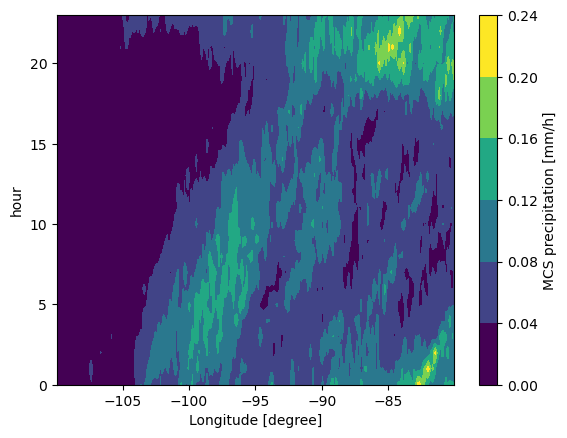

In [16]:
mcspcphovdiur_m1_JJA.plot.contourf()

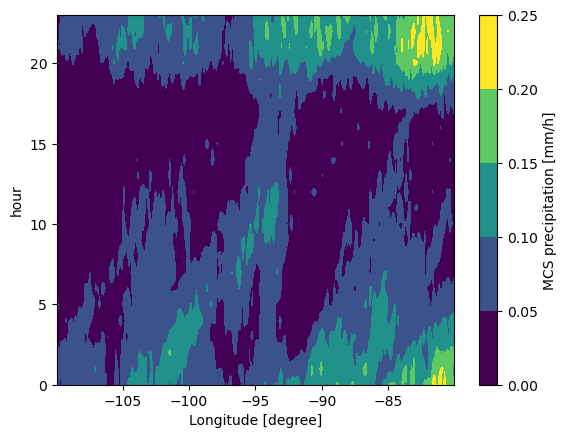

In [17]:
mcspcphovdiur_m2_JJA.plot.contourf()

In [18]:
# Time resolution of data
dt = np.mean(np.diff(totpcphovdiur_obs_MAM.hour.data))
print(f'Time resolution of data: {dt} hour')

# Make hour bins
hours = np.arange(0, 24.1, dt)
nbins = len(hours)

# Time zone shift from UTC to Local Time (LT)
# timezone_shift = int(-6 / dt)

# Deliberately shift time +6 hours ahead, so that the LT starts from noon
# This is just for making a nicer plot over midnight
timezone_shift = int(6 / dt)
print(f'Local time zone shift: {timezone_shift}')

Time resolution of data: 1.0 hour
Local time zone shift: 6


In [19]:
# Shift UTC time to LT
totpcphovdiur_obs_lt_MAM = np.roll(totpcphovdiur_obs_MAM, timezone_shift, axis=0)
mcspcphovdiur_obs_lt_MAM = np.roll(mcspcphovdiur_obs_MAM, timezone_shift, axis=0)
totpcphovdiur_obs_lt_JJA = np.roll(totpcphovdiur_obs_JJA, timezone_shift, axis=0)
mcspcphovdiur_obs_lt_JJA = np.roll(mcspcphovdiur_obs_JJA, timezone_shift, axis=0)

# Extend 1 hour at the end of the day and copy the 1st hour values 
# to make a nicer 24 h length
totpcphovdiur_obsE_MAM = np.ndarray((nbins, totpcphovdiur_obs_lt_MAM.shape[1]))
totpcphovdiur_obsE_MAM[0:nbins-1,:] = totpcphovdiur_obs_lt_MAM
totpcphovdiur_obsE_MAM[nbins-1,:] = totpcphovdiur_obs_lt_MAM[0,:]

totpcphovdiur_obsE_JJA = np.ndarray((nbins, totpcphovdiur_obs_lt_JJA.shape[1]))
totpcphovdiur_obsE_JJA[0:nbins-1,:] = totpcphovdiur_obs_lt_JJA
totpcphovdiur_obsE_JJA[nbins-1,:] = totpcphovdiur_obs_lt_JJA[0,:]

mcspcphovdiur_obsE_MAM = np.ndarray((nbins, mcspcphovdiur_obs_lt_MAM.shape[1]))
mcspcphovdiur_obsE_MAM[0:nbins-1,:] = mcspcphovdiur_obs_lt_MAM
mcspcphovdiur_obsE_MAM[nbins-1,:] = mcspcphovdiur_obs_lt_MAM[0,:]

mcspcphovdiur_obsE_JJA = np.ndarray((nbins, mcspcphovdiur_obs_lt_JJA.shape[1]))
mcspcphovdiur_obsE_JJA[0:nbins-1,:] = mcspcphovdiur_obs_lt_JJA
mcspcphovdiur_obsE_JJA[nbins-1,:] = mcspcphovdiur_obs_lt_JJA[0,:]

In [20]:
# Shift UTC time to LT
totpcphovdiur_m1_lt_MAM = np.roll(totpcphovdiur_m1_MAM, timezone_shift, axis=0)
mcspcphovdiur_m1_lt_MAM = np.roll(mcspcphovdiur_m1_MAM, timezone_shift, axis=0)
totpcphovdiur_m1_lt_JJA = np.roll(totpcphovdiur_m1_JJA, timezone_shift, axis=0)
mcspcphovdiur_m1_lt_JJA = np.roll(mcspcphovdiur_m1_JJA, timezone_shift, axis=0)

# Extend 1 hour at the end of the day and copy the 1st hour values 
# to make a nicer 24 h length
totpcphovdiur_m1E_MAM = np.ndarray((nbins, totpcphovdiur_m1_lt_MAM.shape[1]))
totpcphovdiur_m1E_MAM[0:nbins-1,:] = totpcphovdiur_m1_lt_MAM
totpcphovdiur_m1E_MAM[nbins-1,:] = totpcphovdiur_m1_lt_MAM[0,:]

totpcphovdiur_m1E_JJA = np.ndarray((nbins, totpcphovdiur_m1_lt_JJA.shape[1]))
totpcphovdiur_m1E_JJA[0:nbins-1,:] = totpcphovdiur_m1_lt_JJA
totpcphovdiur_m1E_JJA[nbins-1,:] = totpcphovdiur_m1_lt_JJA[0,:]

mcspcphovdiur_m1E_MAM = np.ndarray((nbins, mcspcphovdiur_m1_lt_MAM.shape[1]))
mcspcphovdiur_m1E_MAM[0:nbins-1,:] = mcspcphovdiur_m1_lt_MAM
mcspcphovdiur_m1E_MAM[nbins-1,:] = mcspcphovdiur_m1_lt_MAM[0,:]

mcspcphovdiur_m1E_JJA = np.ndarray((nbins, mcspcphovdiur_m1_lt_JJA.shape[1]))
mcspcphovdiur_m1E_JJA[0:nbins-1,:] = mcspcphovdiur_m1_lt_JJA
mcspcphovdiur_m1E_JJA[nbins-1,:] = mcspcphovdiur_m1_lt_JJA[0,:]

In [21]:
# Shift UTC time to LT
totpcphovdiur_m2_lt_MAM = np.roll(totpcphovdiur_m2_MAM, timezone_shift, axis=0)
mcspcphovdiur_m2_lt_MAM = np.roll(mcspcphovdiur_m2_MAM, timezone_shift, axis=0)
totpcphovdiur_m2_lt_JJA = np.roll(totpcphovdiur_m2_JJA, timezone_shift, axis=0)
mcspcphovdiur_m2_lt_JJA = np.roll(mcspcphovdiur_m2_JJA, timezone_shift, axis=0)

# Extend 1 hour at the end of the day and copy the 1st hour values 
# to make a nicer 24 h length
totpcphovdiur_m2E_MAM = np.ndarray((nbins, totpcphovdiur_m2_lt_MAM.shape[1]))
totpcphovdiur_m2E_MAM[0:nbins-1,:] = totpcphovdiur_m2_lt_MAM
totpcphovdiur_m2E_MAM[nbins-1,:] = totpcphovdiur_m2_lt_MAM[0,:]

totpcphovdiur_m2E_JJA = np.ndarray((nbins, totpcphovdiur_m2_lt_JJA.shape[1]))
totpcphovdiur_m2E_JJA[0:nbins-1,:] = totpcphovdiur_m2_lt_JJA
totpcphovdiur_m2E_JJA[nbins-1,:] = totpcphovdiur_m2_lt_JJA[0,:]

mcspcphovdiur_m2E_MAM = np.ndarray((nbins, mcspcphovdiur_m2_lt_MAM.shape[1]))
mcspcphovdiur_m2E_MAM[0:nbins-1,:] = mcspcphovdiur_m2_lt_MAM
mcspcphovdiur_m2E_MAM[nbins-1,:] = mcspcphovdiur_m2_lt_MAM[0,:]

mcspcphovdiur_m2E_JJA = np.ndarray((nbins, mcspcphovdiur_m2_lt_JJA.shape[1]))
mcspcphovdiur_m2E_JJA[0:nbins-1,:] = mcspcphovdiur_m2_lt_JJA
mcspcphovdiur_m2E_JJA[nbins-1,:] = mcspcphovdiur_m2_lt_JJA[0,:]

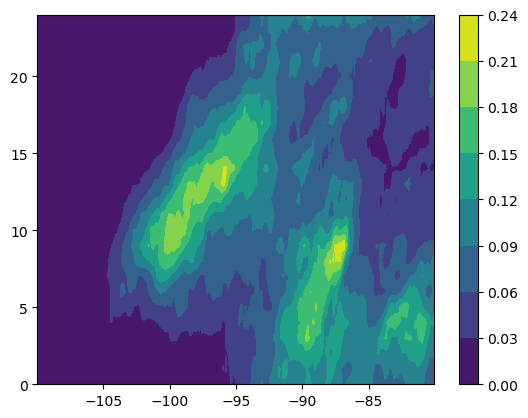

In [22]:
fig, ax = plt.subplots(1,1)
cf = ax.contourf(lon_obs, hours, mcspcphovdiur_obsE_JJA)
fig.colorbar(cf)

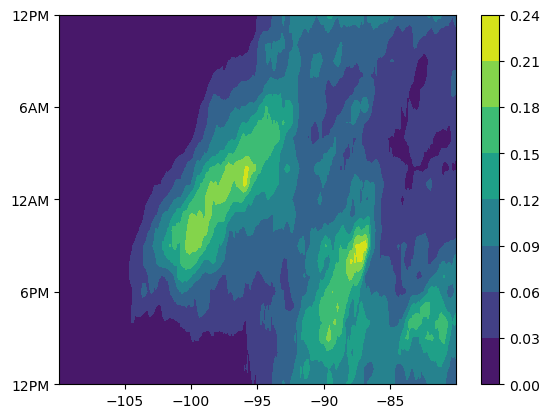

In [23]:
timeval = np.arange(0, 24.1, 6)
timename = ('12PM', '6PM', '12AM', '6AM', '12PM')

fig, ax = plt.subplots(1,1)
cf = ax.contourf(lon_obs, hours, mcspcphovdiur_obsE_JJA)
ax.set_yticks(timeval)
ax.set_yticklabels(timename)
fig.colorbar(cf)

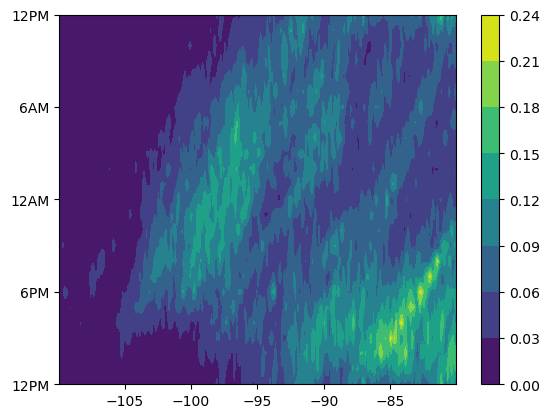

In [24]:
fig, ax = plt.subplots(1,1)
cf = ax.contourf(lon_m1, hours, mcspcphovdiur_m1E_JJA)
ax.set_yticks(timeval)
ax.set_yticklabels(timename)
fig.colorbar(cf)

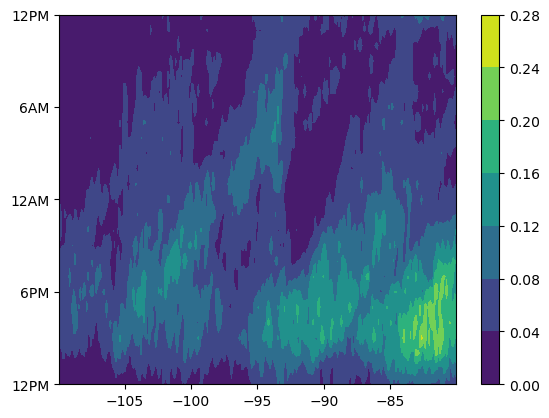

In [25]:
# Roll local time by +12 h to shift the plot from starting at local noon
fig, ax = plt.subplots(1,1)
cf = ax.contourf(lon_m2, hours, mcspcphovdiur_m2E_JJA)
ax.set_yticks(timeval)
ax.set_yticklabels(timename)
fig.colorbar(cf)

In [26]:
# MCS precipitation fraction (OBS)
mcspcpfrac_obsE_MAM = (mcspcphovdiur_obsE_MAM / totpcphovdiur_obsE_MAM)*100
mcspcpfrac_obsE_JJA = (mcspcphovdiur_obsE_JJA / totpcphovdiur_obsE_JJA)*100

mcspcpfrac_m1E_MAM = (mcspcphovdiur_m1E_MAM / totpcphovdiur_m1E_MAM)*100
mcspcpfrac_m1E_MAM = (mcspcphovdiur_m1E_MAM / totpcphovdiur_m1E_MAM)*100
mcspcpfrac_m1E_JJA = (mcspcphovdiur_m1E_JJA / totpcphovdiur_m1E_JJA)*100
mcspcpfrac_m1E_JJA = (mcspcphovdiur_m1E_JJA / totpcphovdiur_m1E_JJA)*100

mcspcpfrac_m2E_MAM = (mcspcphovdiur_m2E_MAM / totpcphovdiur_m2E_MAM)*100
mcspcpfrac_m2E_MAM = (mcspcphovdiur_m2E_MAM / totpcphovdiur_m2E_MAM)*100
mcspcpfrac_m2E_JJA = (mcspcphovdiur_m2E_JJA / totpcphovdiur_m2E_JJA)*100
mcspcpfrac_m2E_JJA = (mcspcphovdiur_m2E_JJA / totpcphovdiur_m2E_JJA)*100

In [27]:
# Compute diurnal cycle amplitude and phase at each longitude
nharm = 8
amp_tot_obs_MAM, phs_tot_obs_MAM, pvar_tot_obs_MAM = harmonic_phase_amplitude2d(np.transpose(totpcphovdiur_obs_lt_MAM), nharm, 0., binsize=dt)
amp_mcs_obs_MAM, phs_mcs_obs_MAM, pvar_mcs_obs_MAM = harmonic_phase_amplitude2d(np.transpose(mcspcphovdiur_obs_lt_MAM), nharm, 0., binsize=dt)
amp_mcsfrac_obs_MAM, phs_mcsfrac_obs_MAM, pvar_mcsfrac_obs_MAM = harmonic_phase_amplitude2d(np.transpose(mcspcpfrac_obsE_MAM), nharm, 0., binsize=dt)

amp_tot_obs_JJA, phs_tot_obs_JJA, pvar_tot_obs_JJA = harmonic_phase_amplitude2d(np.transpose(totpcphovdiur_obs_lt_JJA), nharm, 0., binsize=dt)
amp_mcs_obs_JJA, phs_mcs_obs_JJA, pvar_mcs_obs_JJA = harmonic_phase_amplitude2d(np.transpose(mcspcphovdiur_obs_lt_JJA), nharm, 0., binsize=dt)
amp_mcsfrac_obs_JJA, phs_mcsfrac_obs_JJA, pvar_mcsfrac_obs_JJA = harmonic_phase_amplitude2d(np.transpose(mcspcpfrac_obsE_JJA), nharm, 0., binsize=dt)

In [28]:
# Compute diurnal cycle amplitude and phase at each longitude
amp_tot_m1_MAM, phs_tot_m1_MAM, pvar_tot_m1_MAM = harmonic_phase_amplitude2d(np.transpose(totpcphovdiur_m1_lt_MAM), nharm, 0., binsize=dt)
amp_mcs_m1_MAM, phs_mcs_m1_MAM, pvar_mcs_m1_MAM = harmonic_phase_amplitude2d(np.transpose(mcspcphovdiur_m1_lt_MAM), nharm, 0., binsize=dt)
amp_mcsfrac_m1_MAM, phs_mcsfrac_m1_MAM, pvar_mcsfrac_m1_MAM = harmonic_phase_amplitude2d(np.transpose(mcspcpfrac_m1E_MAM), nharm, 0., binsize=dt)

amp_tot_m1_JJA, phs_tot_m1_JJA, pvar_tot_m1_JJA = harmonic_phase_amplitude2d(np.transpose(totpcphovdiur_m1_lt_JJA), nharm, 0., binsize=dt)
amp_mcs_m1_JJA, phs_mcs_m1_JJA, pvar_mcs_m1_JJA = harmonic_phase_amplitude2d(np.transpose(mcspcphovdiur_m1_lt_JJA), nharm, 0., binsize=dt)
amp_mcsfrac_m1_JJA, phs_mcsfrac_m1_JJA, pvar_mcsfrac_m1_JJA = harmonic_phase_amplitude2d(np.transpose(mcspcpfrac_m1E_JJA), nharm, 0., binsize=dt)

In [29]:
# Compute diurnal cycle amplitude and phase at each longitude
amp_tot_m2_MAM, phs_tot_m2_MAM, pvar_tot_m2_MAM = harmonic_phase_amplitude2d(np.transpose(totpcphovdiur_m2_lt_MAM), nharm, 0., binsize=dt)
amp_mcs_m2_MAM, phs_mcs_m2_MAM, pvar_mcs_m2_MAM = harmonic_phase_amplitude2d(np.transpose(mcspcphovdiur_m2_lt_MAM), nharm, 0., binsize=dt)
amp_mcsfrac_m2_MAM, phs_mcsfrac_m2_MAM, pvar_mcsfrac_m2_MAM = harmonic_phase_amplitude2d(np.transpose(mcspcpfrac_m2E_MAM), nharm, 0., binsize=dt)

amp_tot_m2_JJA, phs_tot_m2_JJA, pvar_tot_m2_JJA = harmonic_phase_amplitude2d(np.transpose(totpcphovdiur_m2_lt_JJA), nharm, 0., binsize=dt)
amp_mcs_m2_JJA, phs_mcs_m2_JJA, pvar_mcs_m2_JJA = harmonic_phase_amplitude2d(np.transpose(mcspcphovdiur_m2_lt_JJA), nharm, 0., binsize=dt)
amp_mcsfrac_m2_JJA, phs_mcsfrac_m2_JJA, pvar_mcsfrac_m2_JJA = harmonic_phase_amplitude2d(np.transpose(mcspcpfrac_m2E_JJA), nharm, 0., binsize=dt)

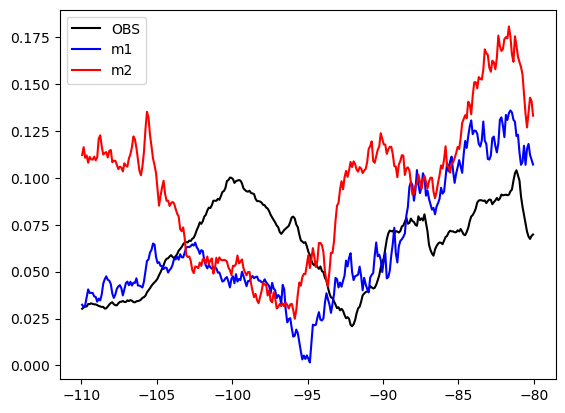

In [30]:
# Quicklook plot to check diurnal amplitude
plt.plot(lon_obs, amp_tot_obs_JJA[:,0], 'k', label='OBS')
plt.plot(lon_m1, amp_tot_m1_JJA[:,0], 'b', label='m1')
plt.plot(lon_m2, amp_tot_m2_JJA[:,0], 'r', label='m2')
plt.legend()

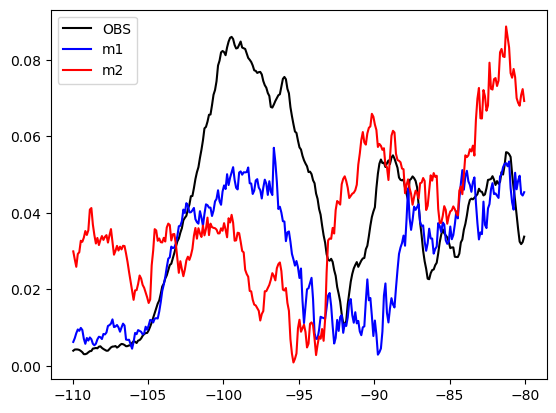

In [31]:
plt.plot(lon_obs, amp_mcs_obs_JJA[:,0], 'k', label='OBS')
plt.plot(lon_m1, amp_mcs_m1_JJA[:,0], 'b', label='m1')
plt.plot(lon_m2, amp_mcs_m2_JJA[:,0], 'r', label='m2')
plt.legend()

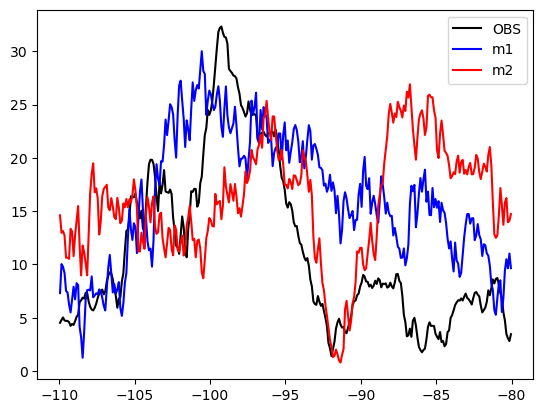

In [32]:
plt.plot(lon_obs, amp_mcsfrac_obs_JJA[:,0], 'k', label='OBS')
plt.plot(lon_m1, amp_mcsfrac_m1_JJA[:,0], 'b', label='m1')
plt.plot(lon_m2, amp_mcsfrac_m2_JJA[:,0], 'r', label='m2')
plt.legend()

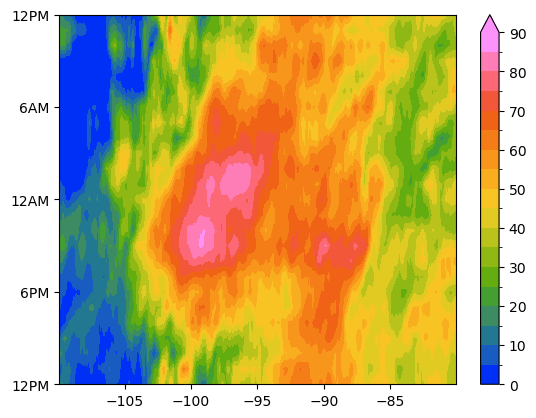

In [33]:
# Quicklook plot for MCS fraction
cmap = cc.cm.CET_R1
levels = np.arange(0, 91, 5)
norm = mpl.colors.BoundaryNorm(boundaries=levels, ncolors=cmap.N)

fig, ax = plt.subplots(1,1)
cf = ax.contourf(lon_obs, hours, mcspcpfrac_obsE_JJA, levels=levels, norm=norm, cmap=cmap, extend='max')
ax.set_yticks(timeval)
ax.set_yticklabels(timename)
fig.colorbar(cf)

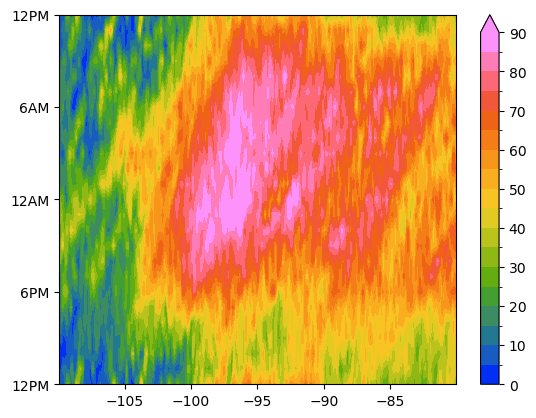

In [34]:
# Quicklook plot for MCS fraction
cmap = cc.cm.CET_R1
levels = np.arange(0, 91, 5)
norm = mpl.colors.BoundaryNorm(boundaries=levels, ncolors=cmap.N)

fig, ax = plt.subplots(1,1)
cf = ax.contourf(lon_m1, hours, mcspcpfrac_m1E_JJA, levels=levels, norm=norm, cmap=cmap, extend='max')
ax.set_yticks(timeval)
ax.set_yticklabels(timename)
fig.colorbar(cf)

## Function to plot diurnal Hovmoller composites

In [35]:
def plot_hov_amp(nrow, ncol, lonarr, time, dataarr, amparr, ampmax, amplabel, ampcolor, levels, cmap, titles, cblabel, figname,
                 xlim=None, reg_lons=None, reg_text=None, reg_colors=None, figsize=None, fontsize=None, linewidth=None,
                 xlables=None, ylabels=None, ylabels2=None, timeval=None, timename=None,
                 wspace=None, hspace=None, wspace0=None, arrow_xy=None):

    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.weight'] = 'regular'
    mpl.rcParams['font.family'] = 'Helvetica'

    fig = plt.figure(figsize=figsize, dpi=100)

    # xlabels = ['','','','','Longitude','Longitude']
    # ylabels = ['Local Time (hour)','','Local Time (hour)','','Local Time (hour)','']
    # ylabels2 = ['',amplabel,'',amplabel,'',amplabel]
    # timeval = np.arange(0, 24.1, 6)
    # timename = ('12PM', '6PM', '12AM', '6AM', '12PM')
    
    # Setup two columns (left: plots, right: colorbar)
    gs0 = gridspec.GridSpec(1, 2, figure=fig, height_ratios=[1], width_ratios=[1,0.02], wspace=wspace0)
    # Setup panels to the left
    h_ratios = list(np.repeat(1,nrow))
    w_ratios = list(np.repeat(1,ncol))
    gs1 = gridspec.GridSpecFromSubplotSpec(nrow, ncol, subplot_spec=gs0[0], height_ratios=h_ratios, width_ratios=w_ratios, wspace=wspace, hspace=hspace)
    # Set up colorbar axes to the right
    gs2 = gridspec.GridSpecFromSubplotSpec(nrow, 1, subplot_spec=gs0[1], height_ratios=h_ratios, width_ratios=[0.02], hspace=hspace)
    
    # Loop over rows and columns
    for row in range(nrow):
        for col in range(ncol):
            # Check if variable is None
            Var = dataarr[row][col]
            if (Var is not None):
                # Setup two columns (left: plot, right: colorbar)
                ax = plt.subplot(gs1[row,col])
                cs = ax.contourf(lonarr[row][col], time, Var, levels[row][col], cmap=cmap[row][col], extend='both')
                ax.plot(xlim, (12,12), 'k--')
                ax.set_yticks(timeval)
                ax.set_yticklabels(timename)
                ax.set_xlabel(xlabels[row][col], fontweight='regular')
                ax.set_ylabel(ylabels[row][col], fontweight='regular')
                ax.set_title(titles[row][col], loc='left', fontweight='regular')
                ax.set_xlim(xlim)
                # Annotate Great Plains
                if reg_lons is not None:
                    ax.axvline(x=min(reg_lons), color=reg_colors[row][col], ls='--', lw=2)
                    ax.axvline(x=max(reg_lons), color=reg_colors[row][col], ls='--', lw=2)
                    ax.text(-96, 21, reg_text, color=reg_colors[row][col], fontsize=fontsize*1.5, ha='center', clip_on=True, weight='bold')
                # Diurnal amplitude
                ax2 = ax.twinx()
                p2 = ax2.plot(lonarr[row][col], amparr[row][col], color=ampcolor[row][col], lw=linewidth)
                ax2.yaxis.label.set_color(ampcolor[row][col])
                ax2.set_ylabel(ylabels2[row][col])
                tkw = dict(size=5, width=1.5)
                ax2.tick_params(axis='y', colors=ampcolor[row][col], **tkw)
                ax2.set_ylim(0, ampmax[row][col])
                
                # Draw an arrow to show the direction of time increase
                if (arrow_xy is not None) & (col == 0):
                    ax.annotate('', xy=arrow_xy[0], xycoords='axes fraction', xytext=arrow_xy[1], 
                                arrowprops=dict(arrowstyle="->", facecolor='k', lw=3))
    
        # Colorbar (1 for each row)
        cax = plt.subplot(gs2[row])
        cb1 = plt.colorbar(cs, cax=cax, label=cblabel[row][col], orientation='vertical')
            
    fig.savefig(figname, dpi=300, bbox_inches='tight', facecolor='w')
    return fig

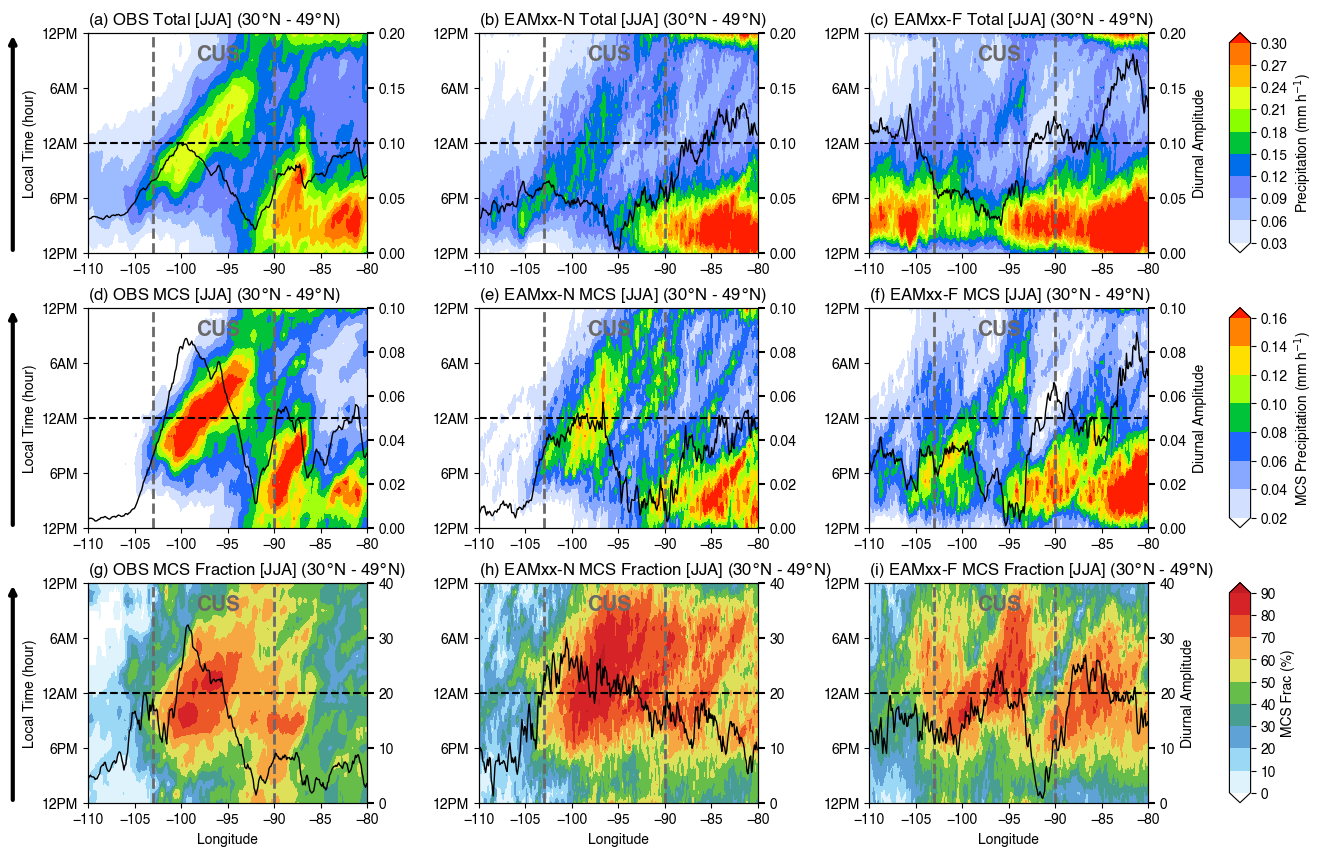

In [40]:
season = 'JJA'
lonarr = [[lon_obs, lon_m1, lon_m2], [lon_obs, lon_m1, lon_m2], [lon_obs, lon_m1, lon_m2]]
dataarray = [
    [totpcphovdiur_obsE_JJA, totpcphovdiur_m1E_JJA, totpcphovdiur_m2E_JJA],
    [mcspcphovdiur_obsE_JJA, mcspcphovdiur_m1E_JJA, mcspcphovdiur_m2E_JJA],
    [mcspcpfrac_obsE_JJA, mcspcpfrac_m1E_JJA, mcspcpfrac_m2E_JJA],
]
amparr = [
    [amp_tot_obs_JJA[:,0], amp_tot_m1_JJA[:,0], amp_tot_m2_JJA[:,0],], 
    [amp_mcs_obs_JJA[:,0], amp_mcs_m1_JJA[:,0],  amp_mcs_m2_JJA[:,0],],  
    [amp_mcsfrac_obs_JJA[:,0], amp_mcsfrac_m1_JJA[:,0], amp_mcsfrac_m2_JJA[:,0]],
]
nrow = len(dataarray)
ncol = len(dataarray[0])
wspace = 0.4
hspace = 0.25
wspace0 = 0.15

linewidth = 1
ampmax = [[0.2]*ncol, [0.1]*ncol, [40]*ncol]
levelstot = np.arange(0.03, 0.301, 0.03)
levelsmcs = np.arange(0.02, 0.161, 0.02)
levelsfrac = np.arange(0, 90.1, 10)
levelsarr = [
    [levelstot]*ncol, 
    [levelsmcs]*ncol, 
    [levelsfrac]*ncol,
]
amplabel = 'Diurnal Amplitude'
# ampcolor = [['orangered']*ncol,['orangered']*ncol,['k']*ncol]
ampcolor = [['k']*ncol,['k']*ncol,['k']*ncol]
# cmapfrac = cc.cm.CET_R1
cmappcp = generate_NCL_cmap('precip3_16lev', cont_opt=True, cont_param_n=16, cont_param_ws='sRGB')
cmapfrac = generate_NCL_cmap('WhiteBlueGreenYellowRed')
cmapfrac = truncate_colormap(cmapfrac, 0.0, 0.9)
cmaparr = [
    [cmappcp]*ncol,
    [cmappcp]*ncol,
    [cmapfrac]*ncol,
]
cblabel = [
    ['Precipitation (mm h$^{-1}$)']*ncol,
    ['MCS Precipitation (mm h$^{-1}$)']*ncol,
    ['MCS Frac (%)']*ncol,
]
lat_band = f' ({np.abs(startlat):.0f}' + r'$\degree$N - ' + f'{np.abs(endlat):.0f}' + r'$\degree$N)'
xlim = (startlon, endlon)
titles = [
    [f"(a) {name_map2['obs']} Total [{season}]"+lat_band, f"(b) {name_map2['m1']} Total [{season}]"+lat_band, f"(c) {name_map2['m2']} Total [{season}]"+lat_band,],
    [f"(d) {name_map2['obs']} MCS [{season}]"+lat_band, f"(e) {name_map2['m1']} MCS [{season}]"+lat_band, f"(f) {name_map2['m2']} MCS [{season}]"+lat_band,],
    [f"(g) {name_map2['obs']} MCS Fraction [{season}]"+lat_band, f"(h) {name_map2['m1']} MCS Fraction [{season}]"+lat_band, f"(i) {name_map2['m2']} MCS Fraction [{season}]"+lat_band,],
]

xlabels = [['']*ncol,['']*ncol,['Longitude']*ncol]
ylabels = [['Local Time (hour)','','']]*nrow
ylabels2 = [['','',amplabel]]*nrow
timeval = np.arange(0, 24.1, 6)
timename = ('12PM', '6PM', '12AM', '6AM', '12PM')
    
reg_lons = [-103., -90]
# reg_colors = [['white']*ncol,['white']*ncol,['dimgray']*ncol]
reg_colors = [['dimgray']*ncol,['dimgray']*ncol,['dimgray']*ncol]
reg_text = region
figsize = (15,10)
fontsize = 10
arrow_xy = [(-0.27, 1),(-0.27,0)]
figname = f"{figdir}obs_scream_tot_mcs_rainhov_diurnal_{region}_{season}.png"

fig = plot_hov_amp(nrow, ncol, lonarr, hours, dataarray, amparr, ampmax, amplabel, ampcolor, levelsarr, cmaparr, titles, cblabel, figname,
                   xlim=xlim, reg_lons=reg_lons, reg_colors=reg_colors, reg_text=reg_text, figsize=figsize, fontsize=fontsize, linewidth=linewidth,
                   xlables=xlabels, ylabels=ylabels, ylabels2=ylabels2, timeval=timeval, timename=timename,
                   wspace=wspace, hspace=hspace, wspace0=wspace0, arrow_xy=arrow_xy)

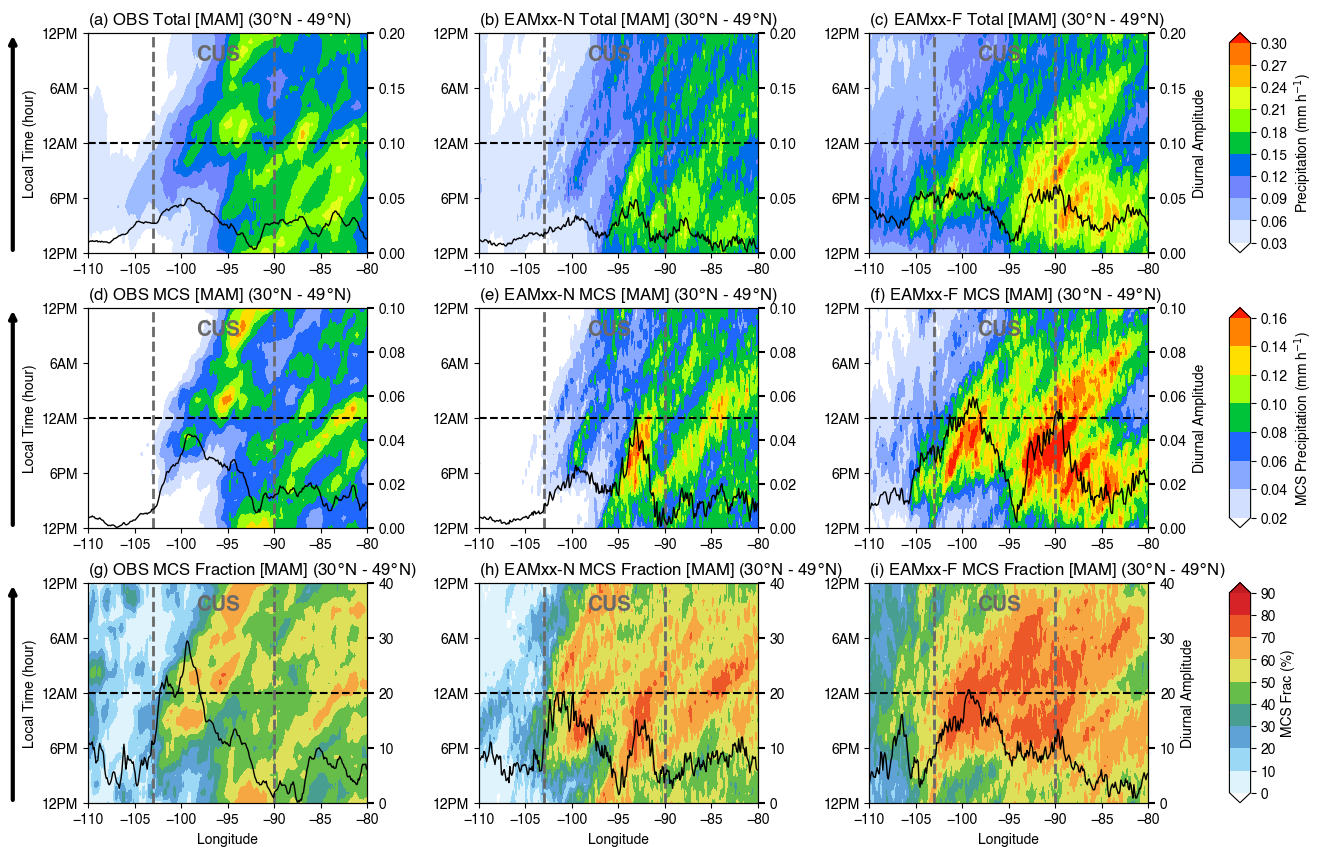

In [41]:
season = 'MAM'
lonarr = [[lon_obs, lon_m1, lon_m2], [lon_obs, lon_m1, lon_m2], [lon_obs, lon_m1, lon_m2]]
dataarray = [
    [totpcphovdiur_obsE_MAM, totpcphovdiur_m1E_MAM, totpcphovdiur_m2E_MAM],
    [mcspcphovdiur_obsE_MAM, mcspcphovdiur_m1E_MAM, mcspcphovdiur_m2E_MAM],
    [mcspcpfrac_obsE_MAM, mcspcpfrac_m1E_MAM, mcspcpfrac_m2E_MAM],
]
amparr = [
    [amp_tot_obs_MAM[:,0], amp_tot_m1_MAM[:,0], amp_tot_m2_MAM[:,0],], 
    [amp_mcs_obs_MAM[:,0], amp_mcs_m1_MAM[:,0],  amp_mcs_m2_MAM[:,0],],  
    [amp_mcsfrac_obs_MAM[:,0], amp_mcsfrac_m1_MAM[:,0], amp_mcsfrac_m2_MAM[:,0]],
]
nrow = len(dataarray)
ncol = len(dataarray[0])
wspace = 0.4
hspace = 0.25
wspace0 = 0.15

linewidth = 1
ampmax = [[0.2]*ncol, [0.1]*ncol, [40]*ncol]
levelstot = np.arange(0.03, 0.301, 0.03)
levelsmcs = np.arange(0.02, 0.161, 0.02)
levelsfrac = np.arange(0, 90.1, 10)
levelsarr = [
    [levelstot]*ncol, 
    [levelsmcs]*ncol, 
    [levelsfrac]*ncol,
]
amplabel = 'Diurnal Amplitude'
# ampcolor = [['orangered']*ncol,['orangered']*ncol,['k']*ncol]
ampcolor = [['k']*ncol,['k']*ncol,['k']*ncol]
# cmapfrac = cc.cm.CET_R1
cmappcp = generate_NCL_cmap('precip3_16lev', cont_opt=True, cont_param_n=16, cont_param_ws='sRGB')
cmapfrac = generate_NCL_cmap('WhiteBlueGreenYellowRed')
cmapfrac = truncate_colormap(cmapfrac, 0.0, 0.9)
cmaparr = [
    [cmappcp]*ncol,
    [cmappcp]*ncol,
    [cmapfrac]*ncol,
]
cblabel = [
    ['Precipitation (mm h$^{-1}$)']*ncol,
    ['MCS Precipitation (mm h$^{-1}$)']*ncol,
    ['MCS Frac (%)']*ncol,
]
lat_band = f' ({np.abs(startlat):.0f}' + r'$\degree$N - ' + f'{np.abs(endlat):.0f}' + r'$\degree$N)'
xlim = (startlon, endlon)
titles = [
    [f"(a) {name_map2['obs']} Total [{season}]"+lat_band, f"(b) {name_map2['m1']} Total [{season}]"+lat_band, f"(c) {name_map2['m2']} Total [{season}]"+lat_band,],
    [f"(d) {name_map2['obs']} MCS [{season}]"+lat_band, f"(e) {name_map2['m1']} MCS [{season}]"+lat_band, f"(f) {name_map2['m2']} MCS [{season}]"+lat_band,],
    [f"(g) {name_map2['obs']} MCS Fraction [{season}]"+lat_band, f"(h) {name_map2['m1']} MCS Fraction [{season}]"+lat_band, f"(i) {name_map2['m2']} MCS Fraction [{season}]"+lat_band,],
]

xlabels = [['']*ncol,['']*ncol,['Longitude']*ncol]
ylabels = [['Local Time (hour)','','']]*nrow
ylabels2 = [['','',amplabel]]*nrow
timeval = np.arange(0, 24.1, 6)
timename = ('12PM', '6PM', '12AM', '6AM', '12PM')
    
reg_lons = [-103., -90]
# reg_colors = [['white']*ncol,['white']*ncol,['dimgray']*ncol]
reg_colors = [['dimgray']*ncol,['dimgray']*ncol,['dimgray']*ncol]
reg_text = region
figsize = (15,10)
fontsize = 10
arrow_xy = [(-0.27, 1),(-0.27,0)]
figname = f'{figdir}obs_scream_tot_mcs_rainhov_diurnal_{region}_{season}.png'

fig = plot_hov_amp(nrow, ncol, lonarr, hours, dataarray, amparr, ampmax, amplabel, ampcolor, levelsarr, cmaparr, titles, cblabel, figname,
                   xlim=xlim, reg_lons=reg_lons, reg_colors=reg_colors, reg_text=reg_text, figsize=figsize, fontsize=fontsize, linewidth=linewidth,
                   xlables=xlabels, ylabels=ylabels, ylabels2=ylabels2, timeval=timeval, timename=timename,
                   wspace=wspace, hspace=hspace, wspace0=wspace0, arrow_xy=arrow_xy)

In [42]:
figdir

'/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/'

## Plot a map showing the Hovmoller region

/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/rainhov_diurnal_map_CUS.png


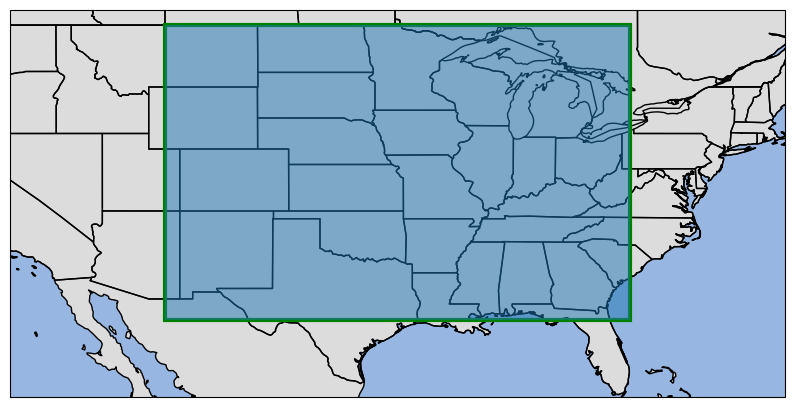

In [44]:
mpl.rcParams['font.family'] = 'Helvetica'
fig = plt.figure(figsize=[10,6], dpi=100)
proj = ccrs.PlateCarree(central_longitude=0)
ax = plt.subplot(111, projection=proj)

resolution = '50m'
land = cfeature.NaturalEarthFeature('physical', 'land', resolution)
ocean = cfeature.NaturalEarthFeature('physical', 'ocean', resolution)
borders = cfeature.NaturalEarthFeature('cultural', 'admin_0_boundary_lines_land', resolution)
states = cfeature.NaturalEarthFeature('cultural', 'admin_1_states_provinces_lakes', resolution)

# map_extent = [startlon-10,endlon+10,startlat-10,endlat+10]
map_extent = [startlon-10,endlon+10,25,50]
ax.set_extent(map_extent, proj)
# Plot map features
ax.add_feature(ocean, edgecolor='none', facecolor=cfeature.COLORS['water'])
ax.add_feature(land, facecolor='gainsboro', edgecolor='k')
ax.add_feature(borders, edgecolor='k', facecolor='none')
ax.add_feature(states, edgecolor='k', facecolor='none')

# Define the vertices of the rectangle in the projection coordinates
x1, y1 = proj.transform_point(startlon, startlat, proj)
x2, y2 = proj.transform_point(endlon, endlat, proj)
# Plot rectangle
ax.add_patch(mpl.patches.Rectangle((x1, y1), x2-x1, y2-y1, transform=proj, fill=None, lw=3, edgecolor='g', zorder=10))
ax.add_patch(mpl.patches.Rectangle((x1, y1), x2-x1, y2-y1, transform=proj, fill='g', edgecolor=None, alpha=0.5, zorder=10))

figname = f'{figdir}rainhov_diurnal_map_{region}.png'
fig.savefig(figname, dpi=300, bbox_inches='tight', facecolor='w')
print(f'{figname}')

In [45]:
figdir

'/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess/conus/figures/'

## Further average over a longitude band to calculate a simple diurnal cycle

In [46]:
lon_band = [-103.0, -95.0]

totpcpdiur_obs_MAM = dsobs.precipitation.sel(lon=slice(min(lon_band), max(lon_band)), time=dsobs['time.season'] == 'MAM').groupby('time.hour').mean(dim=('time','lon'))
totpcpdiur_m1_MAM = dsm1.precipitation.sel(lon=slice(min(lon_band), max(lon_band)), time=dsm1['time.season'] == 'MAM').groupby('time.hour').mean(dim=('time','lon'))
totpcpdiur_m2_MAM = dsm2.precipitation.sel(lon=slice(min(lon_band), max(lon_band)), time=dsm2['time.season'] == 'MAM').groupby('time.hour').mean(dim=('time','lon'))

mcspcpdiur_obs_MAM = dsobs.mcs_precipitation.sel(lon=slice(min(lon_band), max(lon_band)), time=dsobs['time.season'] == 'MAM').groupby('time.hour').mean(dim=('time','lon'))
mcspcpdiur_m1_MAM = dsm1.mcs_precipitation.sel(lon=slice(min(lon_band), max(lon_band)), time=dsm1['time.season'] == 'MAM').groupby('time.hour').mean(dim=('time','lon'))
mcspcpdiur_m2_MAM = dsm2.mcs_precipitation.sel(lon=slice(min(lon_band), max(lon_band)), time=dsm2['time.season'] == 'MAM').groupby('time.hour').mean(dim=('time','lon'))

nonmcspcpdiur_obs_MAM = totpcpdiur_obs_MAM - mcspcpdiur_obs_MAM
nonmcspcpdiur_m1_MAM = totpcpdiur_m1_MAM - mcspcpdiur_m1_MAM
nonmcspcpdiur_m2_MAM = totpcpdiur_m2_MAM - mcspcpdiur_m2_MAM

# Time zone shift from UTC to Local Time (LT)
timezone_shift = int(-6 / dt)

# Shift UTC to local time
mcspcpdiur_obs_lt_MAM = np.roll(mcspcpdiur_obs_MAM, timezone_shift)
mcspcpdiur_m1_lt_MAM = np.roll(mcspcpdiur_m1_MAM, timezone_shift)
mcspcpdiur_m2_lt_MAM = np.roll(mcspcpdiur_m2_MAM, timezone_shift)

nonmcspcpdiur_obs_lt_MAM = np.roll(nonmcspcpdiur_obs_MAM, timezone_shift)
nonmcspcpdiur_m1_lt_MAM = np.roll(nonmcspcpdiur_m1_MAM, timezone_shift)
nonmcspcpdiur_m2_lt_MAM = np.roll(nonmcspcpdiur_m2_MAM, timezone_shift)

In [47]:
totpcpdiur_obs_JJA = dsobs.precipitation.sel(lon=slice(min(lon_band), max(lon_band)), time=dsobs['time.season'] == 'JJA').groupby('time.hour').mean(dim=('time','lon'))
totpcpdiur_m1_JJA = dsm1.precipitation.sel(lon=slice(min(lon_band), max(lon_band)), time=dsm1['time.season'] == 'JJA').groupby('time.hour').mean(dim=('time','lon'))
totpcpdiur_m2_JJA = dsm2.precipitation.sel(lon=slice(min(lon_band), max(lon_band)), time=dsm2['time.season'] == 'JJA').groupby('time.hour').mean(dim=('time','lon'))

mcspcpdiur_obs_JJA = dsobs.mcs_precipitation.sel(lon=slice(min(lon_band), max(lon_band)), time=dsobs['time.season'] == 'JJA').groupby('time.hour').mean(dim=('time','lon'))
mcspcpdiur_m1_JJA = dsm1.mcs_precipitation.sel(lon=slice(min(lon_band), max(lon_band)), time=dsm1['time.season'] == 'JJA').groupby('time.hour').mean(dim=('time','lon'))
mcspcpdiur_m2_JJA = dsm2.mcs_precipitation.sel(lon=slice(min(lon_band), max(lon_band)), time=dsm2['time.season'] == 'JJA').groupby('time.hour').mean(dim=('time','lon'))

nonmcspcpdiur_obs_JJA = totpcpdiur_obs_JJA - mcspcpdiur_obs_JJA
nonmcspcpdiur_m1_JJA = totpcpdiur_m1_JJA - mcspcpdiur_m1_JJA
nonmcspcpdiur_m2_JJA = totpcpdiur_m2_JJA - mcspcpdiur_m2_JJA

# Shift UTC to local time
mcspcpdiur_obs_lt_JJA = np.roll(mcspcpdiur_obs_JJA, timezone_shift)
mcspcpdiur_m1_lt_JJA = np.roll(mcspcpdiur_m1_JJA, timezone_shift)
mcspcpdiur_m2_lt_JJA = np.roll(mcspcpdiur_m2_JJA, timezone_shift)

nonmcspcpdiur_obs_lt_JJA = np.roll(nonmcspcpdiur_obs_JJA, timezone_shift)
nonmcspcpdiur_m1_lt_JJA = np.roll(nonmcspcpdiur_m1_JJA, timezone_shift)
nonmcspcpdiur_m2_lt_JJA = np.roll(nonmcspcpdiur_m2_JJA, timezone_shift)

## Calculate 1D diurnal cycle amplitude, phase and variance explained

In [48]:
# Compute diurnal cycle amplitude and phase
nharm = 8

amp1d_mcs_obs_MAM, phs1d_mcs_obs_MAM, pvar1d_mcs_obs_MAM = harmonic_phase_amplitude(mcspcpdiur_obs_MAM.load().data, nharm, 0., binsize=dt)
amp1d_mcs_m1_MAM, phs1d_mcs_m1_MAM, pvar1d_mcs_m1_MAM = harmonic_phase_amplitude(mcspcpdiur_m1_MAM.load().data, nharm, 0., binsize=dt)
amp1d_mcs_m2_MAM, phs1d_mcs_m2_MAM, pvar1d_mcs_m2_MAM = harmonic_phase_amplitude(mcspcpdiur_m2_MAM.load().data, nharm, 0., binsize=dt)

amp1d_nonmcs_obs_MAM, phs1d_nonmcs_obs_MAM, pvar1d_nonmcs_obs_MAM = harmonic_phase_amplitude(nonmcspcpdiur_obs_MAM.load().data, nharm, 0., binsize=dt)
amp1d_nonmcs_m1_MAM, phs1d_nonmcs_m1_MAM, pvar1d_nonmcs_m1_MAM = harmonic_phase_amplitude(nonmcspcpdiur_m1_MAM.load().data, nharm, 0., binsize=dt)
amp1d_nonmcs_m2_MAM, phs1d_nonmcs_m2_MAM, pvar1d_nonmcs_m2_MAM = harmonic_phase_amplitude(nonmcspcpdiur_m2_MAM.load().data, nharm, 0., binsize=dt)

amp1d_mcs_obs_JJA, phs1d_mcs_obs_JJA, pvar1d_mcs_obs_JJA = harmonic_phase_amplitude(mcspcpdiur_obs_JJA.load().data, nharm, 0., binsize=dt)
amp1d_mcs_m1_JJA, phs1d_mcs_m1_JJA, pvar1d_mcs_m1_JJA = harmonic_phase_amplitude(mcspcpdiur_m1_JJA.load().data, nharm, 0., binsize=dt)
amp1d_mcs_m2_JJA, phs1d_mcs_m2_JJA, pvar1d_mcs_m2_JJA = harmonic_phase_amplitude(mcspcpdiur_m2_JJA.load().data, nharm, 0., binsize=dt)

amp1d_nonmcs_obs_JJA, phs1d_nonmcs_obs_JJA, pvar1d_nonmcs_obs_JJA = harmonic_phase_amplitude(nonmcspcpdiur_obs_JJA.load().data, nharm, 0., binsize=dt)
amp1d_nonmcs_m1_JJA, phs1d_nonmcs_m1_JJA, pvar1d_nonmcs_m1_JJA = harmonic_phase_amplitude(nonmcspcpdiur_m1_JJA.load().data, nharm, 0., binsize=dt)
amp1d_nonmcs_m2_JJA, phs1d_nonmcs_m2_JJA, pvar1d_nonmcs_m2_JJA = harmonic_phase_amplitude(nonmcspcpdiur_m2_JJA.load().data, nharm, 0., binsize=dt)

## Plot simple diurnal cycle mean over a region

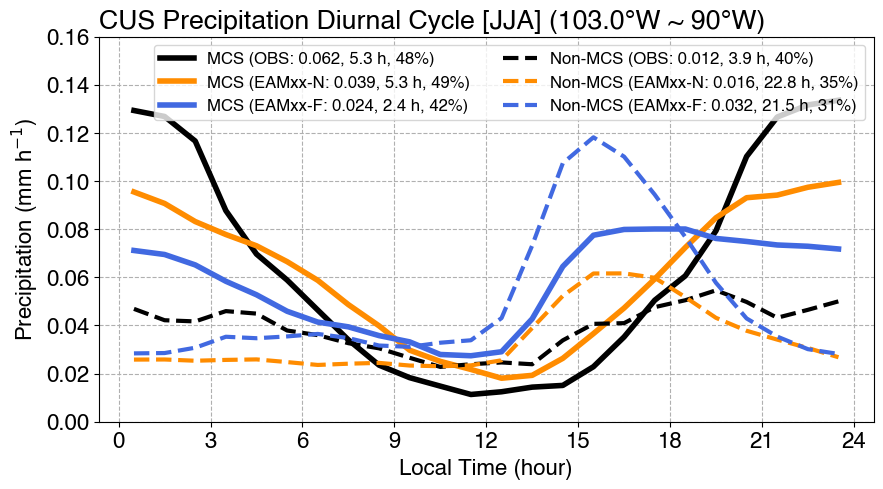

In [54]:
mpl.rcParams['font.size'] = 16
mpl.rcParams['font.family'] = 'Helvetica'

fig, ax = plt.subplots(1,1, figsize=[10,5], dpi=100)
lw_mcs = 4
lw_nonmcs = 3
colors = {'obs':'k', 'm1':'darkorange', 'm2':'royalblue'}

# Legends (amplitude, phase, variance explained by first harmonic)
label_mcs_obs = f"MCS ({name_map2['obs']}: {amp1d_mcs_obs_JJA[0]:.3f}, {phs1d_mcs_obs_JJA[0]:.1f} h, {pvar1d_mcs_obs_JJA[0]:.0f}%)"
label_mcs_m1 = f"MCS ({name_map2['m1']}: {amp1d_mcs_m1_JJA[0]:.3f}, {phs1d_mcs_m1_JJA[0]:.1f} h, {pvar1d_mcs_m1_JJA[0]:.0f}%)"
label_mcs_m2 = f"MCS ({name_map2['m2']}: {amp1d_mcs_m2_JJA[0]:.3f}, {phs1d_mcs_m2_JJA[0]:.1f} h, {pvar1d_mcs_m2_JJA[0]:.0f}%)"
label_nonmcs_obs = f"Non-MCS ({name_map2['obs']}: {amp1d_nonmcs_obs_JJA[0]:.3f}, {phs1d_nonmcs_obs_JJA[0]:.1f} h, {pvar1d_nonmcs_obs_JJA[0]:.0f}%)"
label_nonmcs_m1 = f"Non-MCS ({name_map2['m1']}: {amp1d_nonmcs_m1_JJA[0]:.3f}, {phs1d_nonmcs_m1_JJA[0]:.1f} h, {pvar1d_nonmcs_m1_JJA[0]:.0f}%)"
label_nonmcs_m2 = f"Non-MCS ({name_map2['m2']}: {amp1d_nonmcs_m2_JJA[0]:.3f}, {phs1d_nonmcs_m2_JJA[0]:.1f} h, {pvar1d_nonmcs_m2_JJA[0]:.0f}%)"

# Shift time by half dt to center the data at each time bin
ax.plot(hours[:-1]+dt/2, mcspcpdiur_obs_lt_JJA, color=colors['obs'], lw=lw_mcs, label=label_mcs_obs)
ax.plot(hours[:-1]+dt/2, mcspcpdiur_m1_lt_JJA, color=colors['m1'], lw=lw_mcs, label=label_mcs_m1)
ax.plot(hours[:-1]+dt/2, mcspcpdiur_m2_lt_JJA, color=colors['m2'], lw=lw_mcs, label=label_mcs_m2)
ax.plot(hours[:-1]+dt/2, nonmcspcpdiur_obs_lt_JJA, color=colors['obs'], ls='--', lw=lw_nonmcs, label=label_nonmcs_obs)
ax.plot(hours[:-1]+dt/2, nonmcspcpdiur_m1_lt_JJA, color=colors['m1'], ls='--', lw=lw_nonmcs, label=label_nonmcs_m1)
ax.plot(hours[:-1]+dt/2, nonmcspcpdiur_m2_lt_JJA, color=colors['m2'], ls='--', lw=lw_nonmcs, label=label_nonmcs_m2)
ax.legend(ncol=2, fontsize=12)
ax.set_ylim(0, 0.16)
ax.set_xticks(np.arange(0, 24.1, 3))
ax.set_xlabel('Local Time (hour)')
ax.set_ylabel('Precipitation (mm h$^{-1}$)')
ax.grid(ls='--')
ax.set_title(f"{region} Precipitation Diurnal Cycle [JJA] ({abs(min(reg_lons))}°W ~ {abs(max(reg_lons))}°W)", loc='left')
fig.savefig(f"{figdir}mcs_nonmcs_rain_diurnal_obs_scream_{region}_JJA.png", dpi=300, bbox_inches='tight', facecolor='w')

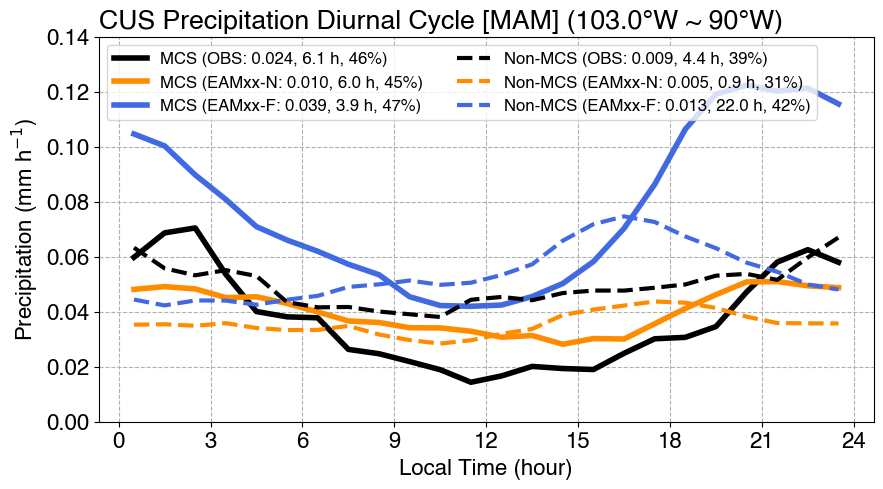

In [53]:
mpl.rcParams['font.size'] = 16
mpl.rcParams['font.family'] = 'Helvetica'

fig, ax = plt.subplots(1,1, figsize=[10,5], dpi=100)
lw_mcs = 4
lw_nonmcs = 3
colors = {'obs':'k', 'm1':'darkorange', 'm2':'royalblue'}

# Legends (amplitude, phase, variance explained by first harmonic)
label_mcs_obs = f"MCS ({name_map2['obs']}: {amp1d_mcs_obs_MAM[0]:.3f}, {phs1d_mcs_obs_MAM[0]:.1f} h, {pvar1d_mcs_obs_MAM[0]:.0f}%)"
label_mcs_m1 = f"MCS ({name_map2['m1']}: {amp1d_mcs_m1_MAM[0]:.3f}, {phs1d_mcs_m1_MAM[0]:.1f} h, {pvar1d_mcs_m1_MAM[0]:.0f}%)"
label_mcs_m2 = f"MCS ({name_map2['m2']}: {amp1d_mcs_m2_MAM[0]:.3f}, {phs1d_mcs_m2_MAM[0]:.1f} h, {pvar1d_mcs_m2_MAM[0]:.0f}%)"
label_nonmcs_obs = f"Non-MCS ({name_map2['obs']}: {amp1d_nonmcs_obs_MAM[0]:.3f}, {phs1d_nonmcs_obs_MAM[0]:.1f} h, {pvar1d_nonmcs_obs_MAM[0]:.0f}%)"
label_nonmcs_m1 = f"Non-MCS ({name_map2['m1']}: {amp1d_nonmcs_m1_MAM[0]:.3f}, {phs1d_nonmcs_m1_MAM[0]:.1f} h, {pvar1d_nonmcs_m1_MAM[0]:.0f}%)"
label_nonmcs_m2 = f"Non-MCS ({name_map2['m2']}: {amp1d_nonmcs_m2_MAM[0]:.3f}, {phs1d_nonmcs_m2_MAM[0]:.1f} h, {pvar1d_nonmcs_m2_MAM[0]:.0f}%)"

# Shift time by half dt to center the data at each time bin
ax.plot(hours[:-1]+dt/2, mcspcpdiur_obs_lt_MAM, color=colors['obs'], lw=lw_mcs, label=label_mcs_obs)
ax.plot(hours[:-1]+dt/2, mcspcpdiur_m1_lt_MAM, color=colors['m1'], lw=lw_mcs, label=label_mcs_m1)
ax.plot(hours[:-1]+dt/2, mcspcpdiur_m2_lt_MAM, color=colors['m2'], lw=lw_mcs, label=label_mcs_m2)
ax.plot(hours[:-1]+dt/2, nonmcspcpdiur_obs_lt_MAM, color=colors['obs'], ls='--', lw=lw_nonmcs, label=label_nonmcs_obs)
ax.plot(hours[:-1]+dt/2, nonmcspcpdiur_m1_lt_MAM, color=colors['m1'], ls='--', lw=lw_nonmcs, label=label_nonmcs_m1)
ax.plot(hours[:-1]+dt/2, nonmcspcpdiur_m2_lt_MAM, color=colors['m2'], ls='--', lw=lw_nonmcs, label=label_nonmcs_m2)
ax.legend(ncol=2, fontsize=12)
ax.set_ylim(0, 0.14)
ax.set_xticks(np.arange(0, 24.1, 3))
ax.set_xlabel('Local Time (hour)')
ax.set_ylabel('Precipitation (mm h$^{-1}$)')
ax.grid(ls='--')
ax.set_title(f'{region} Precipitation Diurnal Cycle [MAM] ({abs(min(reg_lons))}°W ~ {abs(max(reg_lons))}°W)', loc='left')
fig.savefig(f'{figdir}mcs_nonmcs_rain_diurnal_obs_scream_{region}_MAM.png', dpi=300, bbox_inches='tight', facecolor='w')

In [ ]:
figdir